<a href="https://colab.research.google.com/github/ii-shimul/ingeet/blob/mahin/Data_Acquisition_and_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os
import numpy as np
import glob
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [10]:
%pip install -q kaggle

### 1. Kaggle CLI Installation
Installs the Kaggle API tool quietly to enable dataset searching and downloading directly into the Colab environment.

In [11]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle (1).json


### 2. Upload Credentials
Provides an upload prompt to securely upload the `kaggle.json` credentials file required for API authentication.

In [12]:
os.makedirs("/root/.kaggle", exist_ok=True)

shutil.copy(
    "/content/kaggle.json",
    "/root/.kaggle/kaggle.json"
)

os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle API credentials configured!")

Kaggle API credentials configured!


### 3. Configure API Keys
Moves the uploaded `kaggle.json` authentication token to the standard hidden `.kaggle` directory and restricts read/write permissions for security.

### 3. Download and Extract Landmarks
Downloads the 60-class landmark coordinates dataset and extracts the `.npz` archive directly into `/content/landmark_data/`.

In [13]:
!mkdir -p /content/landmark_data

!kaggle datasets download \
    -d mustofahmed/bdslw60-landmarks-v1 \
    -p /content/landmark_data \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/mustofahmed/bdslw60-landmarks-v1
License(s): unknown
100% 345M/345M [00:02<00:00, 178MB/s]



### 4. Verify Dataset Structure
Traverses the dataset directory tree to verify that all 60 class folders are successfully extracted containing their respective landmark files.

In [14]:
data_path = "/content/landmark_data"

total_files = 0
all_classes = set()

for group in os.listdir(data_path):
    group_path = os.path.join(data_path, group)

    if not os.path.isdir(group_path):
        continue

    for word in os.listdir(group_path):
        word_path = os.path.join(group_path, word)

        if not os.path.isdir(word_path):
            continue

        npz_count = sum(
            1 for f in os.listdir(word_path)
            if f.endswith(".npz")
        )

        if npz_count > 0:
            all_classes.add(word)
            total_files += npz_count

print("Total landmark files:", total_files)
print("Total word folders:", len(all_classes))
print("Word labels:")
print(sorted(all_classes))

Total landmark files: 9307
Total word folders: 60
Word labels:
['aam', 'aaple', 'ac', 'aids', 'alu', 'anaros', 'angur', 'apartment', 'attio', 'audio cassette', 'ayna', 'baandej', 'baat', 'baba', 'balti', 'balu', 'bhai', 'biscuts', 'bon', 'boroi', 'bottam', 'bou', 'cake', 'capsule', 'cha', 'chacha', 'chachi', 'chadar', 'chal', 'chikissha', 'chini', 'chips', 'chiruni', 'chocolate', 'chokh utha', 'chosma', 'churi', 'clip', 'cream', 'dada', 'dadi', 'daeitto', 'dal', 'debor', 'denadar', 'dengue', 'doctor', 'dongson', 'dulavai', 'durbol', 'jomoj', 'juta', 'konna', 'maa', 'tattha', 'toothpaste', 'tshirt', 'tubelight', 'tupi', 'tv']


### 5. Inspect Single Sample File
Loads one sample `.npz` file to analyze the array keys, data types, and shape representing frame coordinates (e.g. shape `(frames, 258)`).

In [15]:
# Find all landmark files
npz_files = glob.glob(
    "/content/landmark_data/**/*.npz",
    recursive=True
)

# Handle the case where no NPZ files are found
if not npz_files:
    print("No .npz files found in /content/landmark_data.")
else:
    # Select one sample file
    sample_path = npz_files[0]

    # Load the file
    sample = np.load(sample_path)

    print("Sample file:", sample_path)
    print("Arrays inside the file:")

    # Inspect each array
    for key in sample.files:
        arr = sample[key]
        print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")

Sample file: /content/landmark_data/landmarks_10_15/baat/U14W352F_trial_2_R.npz
Arrays inside the file:
landmarks: shape=(55, 258), dtype=float64


### 6. Build Dataset DataFrame
Maps file paths to class labels and constructs a pandas DataFrame to manage dataset metadata dynamically.

In [16]:
df = pd.DataFrame({
    "file_path": npz_files,
    "label": [os.path.basename(os.path.dirname(path)) for path in npz_files]
})
df.head()

,file_path,label
0,/content/landmark_data/landmarks_10_15/baat/U1...,baat
1,/content/landmark_data/landmarks_10_15/baat/U1...,baat
2,/content/landmark_data/landmarks_10_15/baat/U1...,baat
3,/content/landmark_data/landmarks_10_15/baat/U1...,baat
4,/content/landmark_data/landmarks_10_15/baat/U9...,baat


In [17]:
print("Total sample: ", len(df))
print("Total labels: ", df['label'].nunique())

print("\nThis print show how many video a signle label contain:")
print(df["label"].value_counts().sort_index())

Total sample:  9307
Total labels:  60

This print show how many video a signle label contain:
label
aam               161
aaple             164
ac                118
aids              179
alu               161
anaros            170
angur             155
apartment         145
attio             175
audio cassette    134
ayna              145
baandej           171
baat              203
baba              164
balti             124
balu              140
bhai              163
biscuts           160
bon               161
boroi             138
bottam            130
bou               158
cake              160
capsule           197
cha               151
chacha            162
chachi            167
chadar            127
chal              159
chikissha         186
chini             153
chips             158
chiruni           123
chocolate         169
chokh utha        199
chosma            123
churi             129
clip              123
cream             120
dada              177
dadi              17

In [18]:
print("Missing values: ")
print(df.isnull().sum())

print("\nDuplicate rows: ", df.duplicated().sum())

print("\nDuplicate file paths: ", df['file_path'].duplicated().sum())

Missing values: 
file_path    0
label        0
dtype: int64

Duplicate rows:  0

Duplicate file paths:  0


### 7. Visualize Class Distribution
Plots the sample count per sign category to check for class imbalance across the 60 target classes.

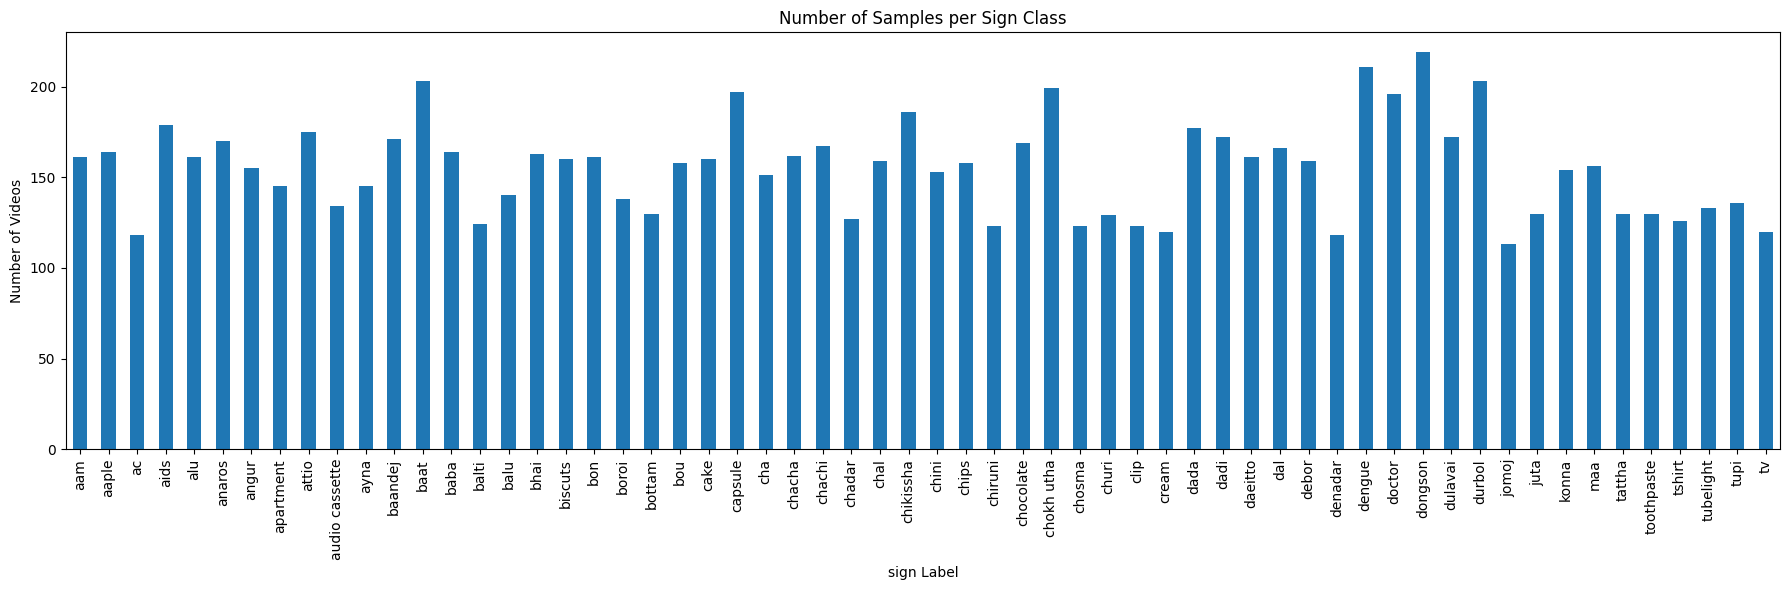

In [19]:
class_counts = df['label'].value_counts().sort_index()
plt.figure(figsize=(18, 6))
class_counts.plot(kind="bar")

plt.title("Number of Samples per Sign Class")
plt.xlabel("sign Label")
plt.ylabel("Number of Videos")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 8. Frame Length Distribution Analysis
Calculates and visualizes the distribution of frame lengths per sample using histogram and scatter plots to decide on an optimal sequence length.

In [20]:
frame_counts = []

for path in df['file_path']:
  try:
    data = np.load(path)
    landmarks = data["landmarks"]
    frame_counts.append(landmarks.shape[0])
  except:
    frame_counts.append(np.nan)


df['frame_count'] = frame_counts
df.head()

,file_path,label,frame_count
0,/content/landmark_data/landmarks_10_15/baat/U1...,baat,55
1,/content/landmark_data/landmarks_10_15/baat/U1...,baat,53
2,/content/landmark_data/landmarks_10_15/baat/U1...,baat,30
3,/content/landmark_data/landmarks_10_15/baat/U1...,baat,43
4,/content/landmark_data/landmarks_10_15/baat/U9...,baat,39


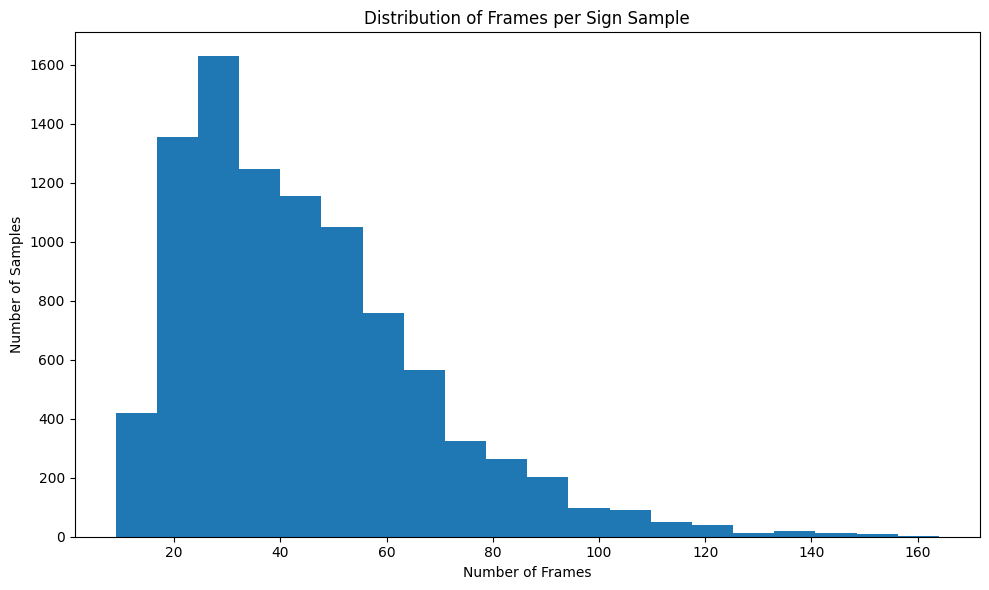

In [21]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["frame_count"].dropna(),
    bins=20
)

plt.title("Distribution of Frames per Sign Sample")
plt.xlabel("Number of Frames")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

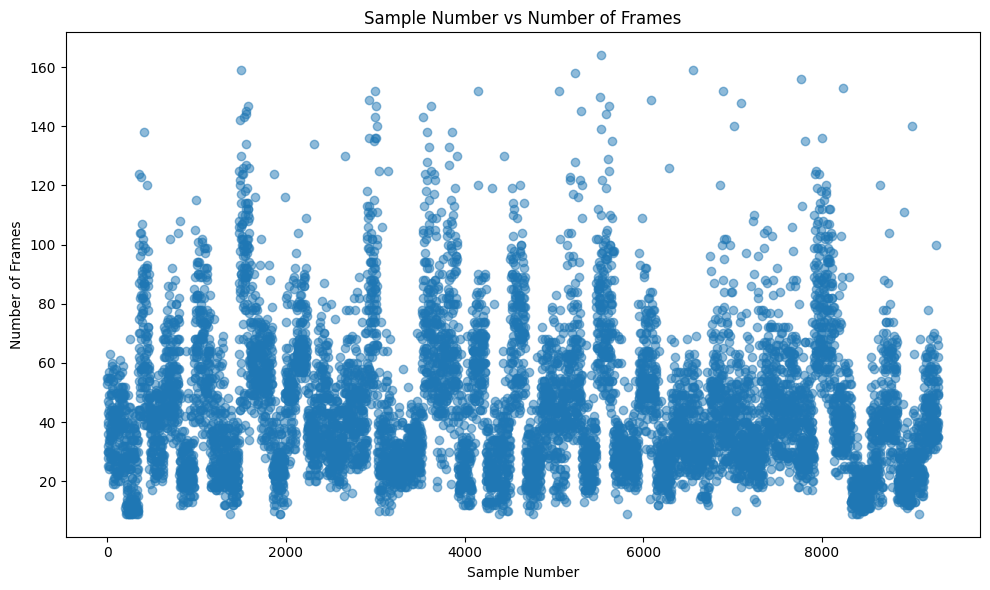

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(
    range(len(df)),
    df["frame_count"],
    alpha=0.5
)

plt.title("Sample Number vs Number of Frames")
plt.xlabel("Sample Number")
plt.ylabel("Number of Frames")

plt.tight_layout()
plt.show()

In [23]:
invalid_files = []
wrong_shape = []
nan_files = []

#print(df['file_path'])

for path in df["file_path"]:
  try:
    data = np.load(path)

    #check landmarks
    if "landmarks" not in data.files:
      invalid_files.append(path)
      continue

    landmarks = data['landmarks']

    # print("Number of values in one frame:", len(landmarks[0]))

    #check shape
    if landmarks.ndim != 2 or landmarks.shape[1] != 258:
      wrong_shape.append((path, landmarks.shape))

    #check Nan or infinite values
    if not np.isfinite(landmarks).all():
      nan_files.append(path)

  except Exception as e:
    invalid_files.append((path, str(e)))

print("Invalid files:", len(invalid_files))
print("Wrong shape:", len(wrong_shape))
print("NaN/Infinite files:", len(nan_files))

Invalid files: 0
Wrong shape: 0
NaN/Infinite files: 0


### 9. Data Cleaning and Integrity Check
Validates that there are no corrupted files, structural mismatches, or `NaN`/infinite coordinates inside the loaded `.npz` arrays.

In [24]:
sample_path = df['file_path'].iloc[0]

data = np.load(sample_path)
landmarks = data['landmarks']

print("File:", sample_path)
print("Shape:", landmarks.shape)
print("Number of frames:", landmarks.shape[0])
print("Features per frame:", landmarks.shape[1])

print("\nFirst frame:")
print(landmarks[0])

File: /content/landmark_data/landmarks_10_15/baat/U14W352F_trial_2_R.npz
Shape: (55, 258)
Number of frames: 55
Features per frame: 258

First frame:
[ 6.04358971e-01  2.78539717e-01 -5.20417094e-01  9.99269783e-01
  6.19494855e-01  2.37059355e-01 -4.80873644e-01  9.98395145e-01
  6.29761219e-01  2.34484673e-01 -4.80897993e-01  9.98387098e-01
  6.39427543e-01  2.32504055e-01 -4.80649412e-01  9.98072505e-01
  5.87895632e-01  2.44230732e-01 -4.69428718e-01  9.98604953e-01
  5.77568948e-01  2.46883854e-01 -4.69345242e-01  9.98777211e-01
  5.68554342e-01  2.49508619e-01 -4.69700485e-01  9.98696506e-01
  6.59534097e-01  2.51804829e-01 -2.47064263e-01  9.98554766e-01
  5.60544431e-01  2.73389876e-01 -1.84711680e-01  9.99011040e-01
  6.26430452e-01  3.21845710e-01 -4.35274363e-01  9.99505162e-01
  5.91341853e-01  3.34399045e-01 -4.18253601e-01  9.99512076e-01
  7.44234085e-01  4.78185773e-01 -2.05768898e-01  9.99274790e-01
  5.20221353e-01  5.02096891e-01 -8.18954781e-02  9.98873174e-01
  8.74

In [25]:
TARGET_FRAMES = 44

def normalize_frames(landmarks):
  num_frames = landmarks.shape[0]

  #Fewer than 44 frames -> zero padding
  if num_frames < TARGET_FRAMES:
    padding = np.zeros(
         (TARGET_FRAMES - num_frames, landmarks.shape[1])
    )
    return np.vstack((landmarks, padding))

  # More than 44 frames → uniform sampling
  elif num_frames > TARGET_FRAMES:
    indices = np.linspace(
        0,
        num_frames - 1,
        TARGET_FRAMES
    ).astype(int)

    return landmarks[indices]

  # Exactly 44 frames → no change
  else:
    return landmarks

### 10. Sequence Length Normalization
Defines a normalization function to standardize frame length to exactly `44` frames using zero-padding (for shorter videos) or uniform sampling (for longer videos).

## Testing for normalize_frames

In [26]:
sample_path = df["file_path"].iloc[18]

data = np.load(sample_path)
landmarks = data["landmarks"]

normalized = normalize_frames(landmarks)

print("Original shape:", landmarks.shape)
print("Normalized shape:", normalized.shape)

Original shape: (46, 258)
Normalized shape: (44, 258)


In [27]:
X = []

for path in df["file_path"]:
    data = np.load(path)
    landmarks = data["landmarks"]

    normalized = normalize_frames(landmarks)
    X.append(normalized)

X = np.array(X)

print("X shape:", X.shape)

X shape: (9307, 44, 258)


### 11. Feature and Label Encoding
Constructs the final NumPy tensor $X$ of shape `(9307, 44, 258)` and encodes the textual categorical labels into integer values $y$.

In [28]:
#verifiy the X
print("Dataset shape:", X.shape)
print("First sample shape:", X[1].shape)
print("First frame shape:", X[1][1].shape)

Dataset shape: (9307, 44, 258)
First sample shape: (44, 258)
First frame shape: (258,)


In [29]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df['label'])

print("y shape: ", y.shape)
print("First 10 labels: ", y[ :10])


#for i, label in enumerate(label_encoder.classes_):
    #print(i, "→", label)

y shape:  (9307,)
First 10 labels:  [12 12 12 12 12 12 12 12 12 12]


In [30]:
#not main part of the code just for varification
print("X[0] shape:", X[0].shape)
print("y[0]:", y[0])
print("Class name:", label_encoder.classes_[y[0]])

X[0] shape: (44, 258)
y[0]: 12
Class name: baat


### 12. Dataset Splitting (70/15/15)
Splits the dataset into Training (70%), Validation (15%), and Test (15%) subsets using stratified splitting to preserve class distributions.

In [31]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size = 0.30,
    random_state= 42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("y_train shape: ", y_train.shape)

print("X_temp shape:", X_temp.shape)
print("y_temp shape:", y_temp.shape)

X_train shape: (6514, 44, 258)
y_train shape:  (6514,)
X_temp shape: (2793, 44, 258)
y_temp shape: (2793,)


In [32]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_val shape: (1396, 44, 258)
y_val shape: (1396,)
X_test shape: (1397, 44, 258)
y_test shape: (1397,)


In [33]:
#verification
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

print("\nClasses in training:", len(np.unique(y_train)))
print("Classes in validation:", len(np.unique(y_val)))
print("Classes in testing:", len(np.unique(y_test)))

Training samples: 6514
Validation samples: 1396
Testing samples: 1397

Classes in training: 60
Classes in validation: 60
Classes in testing: 60


## 13. Save Processed Dataset to Google Drive

To prevent losing your preprocessed variables (`X_train`, `X_val`, `X_test`, labels, and encoder classes) when the Colab session disconnects, we persist them as fast-loading binary `.npy` files directly inside your Google Drive.

### Instructions:
1. Run the Google Drive mount cell below.
2. Authorize Colab to access your Drive.
3. The script will automatically create a folder named `Ishara/processed_data` inside your Drive's root and save the train/validation/test sets successfully.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Define Google Drive storage path
save_path = "/content/drive/MyDrive/Ishara/processed_data"
os.makedirs(save_path, exist_ok=True)
print(f"Directory verified/created at: {save_path}")

In [ ]:
# Save features (cast to float32 to optimize memory footprint)
np.save(os.path.join(save_path, "X_train.npy"), X_train.astype(np.float32))
np.save(os.path.join(save_path, "X_val.npy"), X_val.astype(np.float32))
np.save(os.path.join(save_path, "X_test.npy"), X_test.astype(np.float32))

# Save ground-truth target integer labels
np.save(os.path.join(save_path, "y_train.npy"), y_train)
np.save(os.path.join(save_path, "y_val.npy"), y_val)
np.save(os.path.join(save_path, "y_test.npy"), y_test)

# Save the decoded text labels map (for inverse_transform mapping later)
np.save(os.path.join(save_path, "class_names.npy"), label_encoder.classes_)

print("All dataset splits saved successfully to Google Drive!")